<a href="https://colab.research.google.com/github/Bhumika421/ML-and-AI/blob/main/2431475_BhumikaShrestha_ImageClassification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Image Classification
### Intel Scene Classification | CNN from Scratch + Transfer Learning

In [ ]:
# ── Imports ──────────────────────────────────────────────────────
import os, random, time
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, UnidentifiedImageError

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Input
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Dense, Flatten,
    Dropout, BatchNormalization, GlobalAveragePooling2D)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import regularizers

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

print(f"TensorFlow  : {tf.__version__}")
print(f"GPU devices : {tf.config.list_physical_devices('GPU')}")


TensorFlow  : 2.20.0
GPU devices : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Dataset Setup

In [ ]:
# ── Mount Google Drive ───────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
BASE_DIR  = '/content/drive/MyDrive/AI and ML/Data/Scene Classification'
train_dir = os.path.join(BASE_DIR, '/content/drive/MyDrive/AI and ML/Data/Scene Classification/train')
test_dir  = os.path.join(BASE_DIR, '/content/drive/MyDrive/AI and ML/Data/Scene Classification/test')

status = "Found" if os.path.exists(train_dir) and os.path.exists(test_dir) else " Not found"
print(f"Folders: {status}")

class_list = sorted(os.listdir(train_dir))
print(f"Classes ({len(class_list)}): {class_list}")


Folders: Found
Classes (6): ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


---
# Part A — CNNs from Scratch
## 1. Data Understanding, Analysis & Cleaning

### 1.1 Dataset Description
The **Intel Scene Classification** dataset has **6 natural scene classes**: buildings, forest, glacier, mountain, sea, street. Pre-split into ~14k train and ~3k test images.

=== Training Set ===
Total: 14008
  buildings   :  2184  (15.6%)
  forest      :  2264  (16.2%)
  glacier     :  2397  (17.1%)
  mountain    :  2521  (18.0%)
  sea         :  2267  (16.2%)
  street      :  2375  (17.0%)


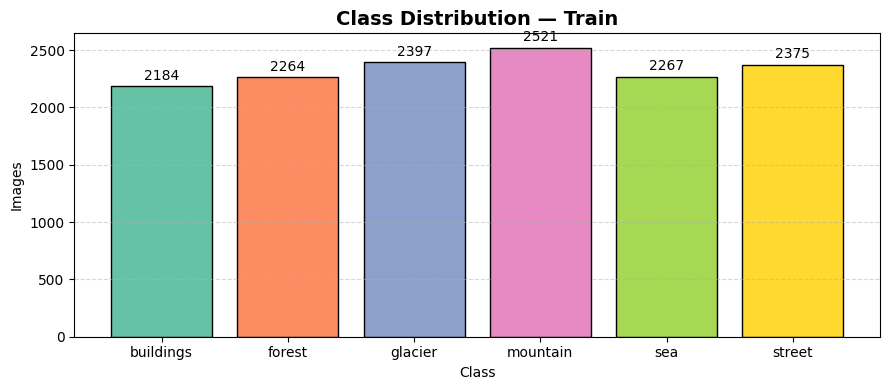


=== Test Set ===
Total: 3000
  buildings   :   437  (14.6%)
  forest      :   474  (15.8%)
  glacier     :   553  (18.4%)
  mountain    :   525  (17.5%)
  sea         :   510  (17.0%)
  street      :   501  (16.7%)


In [ ]:
def count_per_class(root, plot=True, title='Distribution'):
    """Count images per class and optionally plot."""
    counts = {}
    for cls in sorted(os.listdir(root)):
        p = os.path.join(root, cls)
        if os.path.isdir(p):
            counts[cls] = len([f for f in os.listdir(p)
                               if f.lower().endswith(('.jpg','.jpeg','.png'))])
    total = sum(counts.values())
    print(f"Total: {total}")
    for c, n in counts.items():
        print(f"  {c:<12}: {n:>5}  ({100*n/total:.1f}%)")
    if plot:
        fig, ax = plt.subplots(figsize=(9, 4))
        palette = plt.cm.Set2(range(len(counts)))
        bars = ax.bar(counts.keys(), counts.values(), color=palette, edgecolor='black')
        for b, n in zip(bars, counts.values()):
            ax.text(b.get_x()+b.get_width()/2, b.get_height()+30, str(n),
                    ha='center', va='bottom', fontsize=10)
        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.set_xlabel('Class'); ax.set_ylabel('Images')
        ax.grid(axis='y', linestyle='--', alpha=0.5)
        plt.tight_layout(); plt.show()
    return counts

print("=== Training Set ===")
train_counts = count_per_class(train_dir, title='Class Distribution — Train')
print("\n=== Test Set ===")
test_counts  = count_per_class(test_dir,  plot=False)

### 1.2 Train / Validation Split
80% training / 20% validation via `image_dataset_from_directory`. Test set kept unseen for final evaluation.

In [ ]:
def remove_bad_images(root, verbose=False):
    removed = 0
    for cls in sorted(os.listdir(root)):
        cls_p = os.path.join(root, cls)
        if not os.path.isdir(cls_p): continue
        for fname in os.listdir(cls_p):
            fpath = os.path.join(cls_p, fname)
            if not os.path.isfile(fpath): continue
            try:
                with Image.open(fpath) as img: img.verify()
            except (IOError, UnidentifiedImageError):
                os.remove(fpath); removed += 1
                if verbose: print(f"Removed: {fpath}")
    print(f"Corrupted removed: {removed}")

remove_bad_images(train_dir)
remove_bad_images(test_dir)


Corrupted removed: 0
Corrupted removed: 0


In [ ]:
IMG_SIZE   = (150, 150)
BATCH_SIZE = 32

train_raw = tf.keras.utils.image_dataset_from_directory(
    train_dir, validation_split=0.2, subset='training',
    seed=SEED, image_size=IMG_SIZE, batch_size=BATCH_SIZE)

val_raw = tf.keras.utils.image_dataset_from_directory(
    train_dir, validation_split=0.2, subset='validation',
    seed=SEED, image_size=IMG_SIZE, batch_size=BATCH_SIZE)

CLASS_NAMES = train_raw.class_names
NUM_CLASSES = len(CLASS_NAMES)
print(f"Classes ({NUM_CLASSES}): {CLASS_NAMES}")

norm = lambda x, y: (tf.cast(x, tf.float32) / 255.0, y)

train_ds = (train_raw.map(norm, num_parallel_calls=tf.data.AUTOTUNE)
            .cache().shuffle(1000, seed=SEED).prefetch(tf.data.AUTOTUNE))

val_ds = (val_raw.map(norm, num_parallel_calls=tf.data.AUTOTUNE)
          .cache().prefetch(tf.data.AUTOTUNE))


Found 14008 files belonging to 6 classes.
Using 11207 files for training.
Found 14008 files belonging to 6 classes.
Using 2801 files for validation.
Classes (6): ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


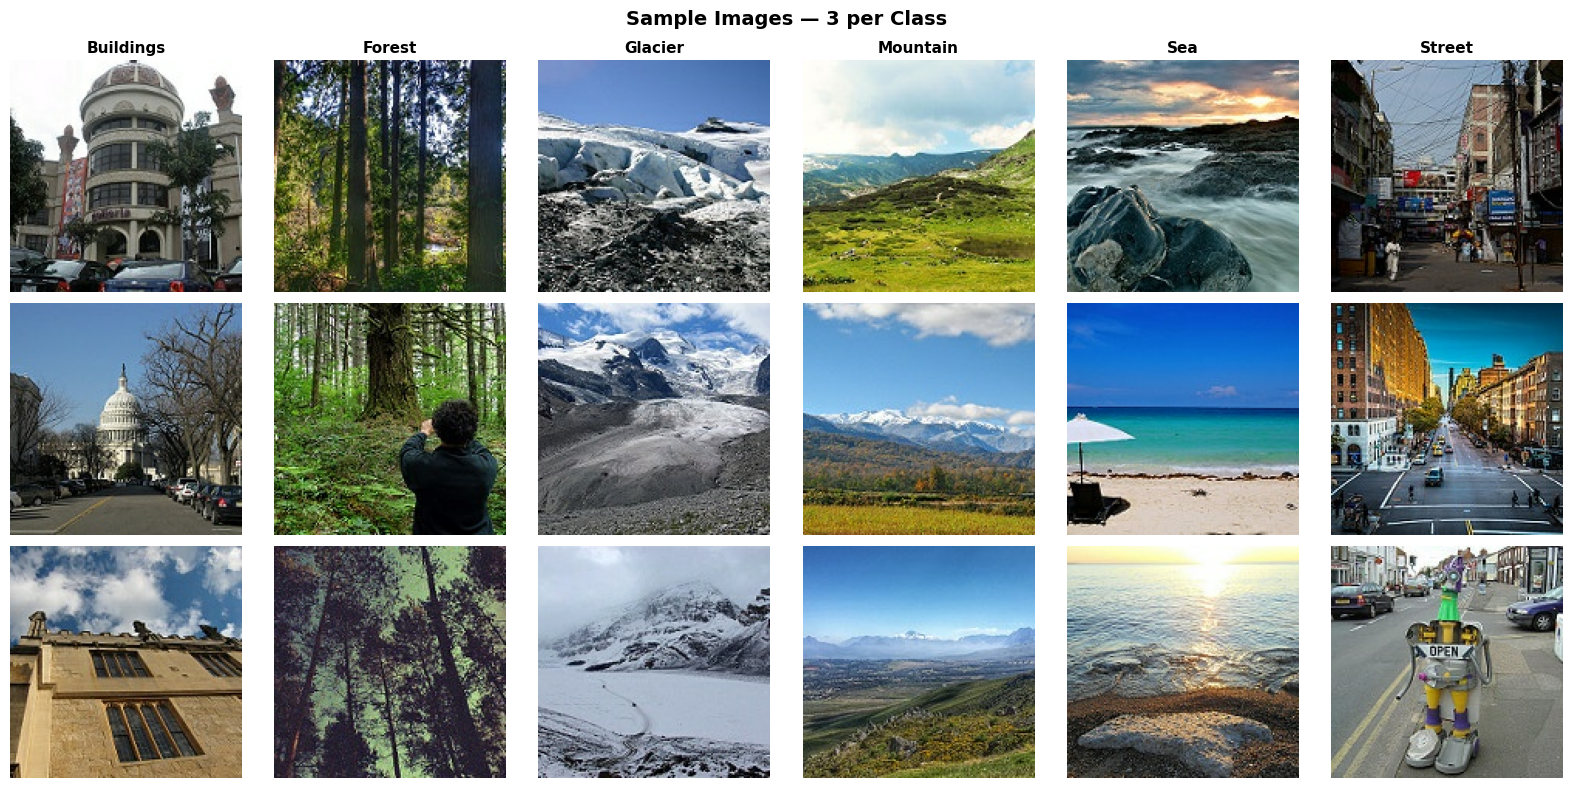

In [ ]:
# Collect 3 sample images per class for visualisation
samples = {c: [] for c in CLASS_NAMES}
for imgs, lbls in train_ds.unbatch().take(2000):
    name = CLASS_NAMES[int(lbls.numpy())]
    if len(samples[name]) < 3:
        samples[name].append(imgs.numpy())
    if all(len(v) == 3 for v in samples.values()):
        break

fig, axes = plt.subplots(3, 6, figsize=(16, 8))
fig.suptitle('Sample Images — 3 per Class', fontsize=14, fontweight='bold')
for col, cls in enumerate(CLASS_NAMES):
    for row in range(3):
        ax = axes[row, col]
        ax.imshow(samples[cls][row]); ax.axis('off')
        if row == 0: ax.set_title(cls.capitalize(), fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()


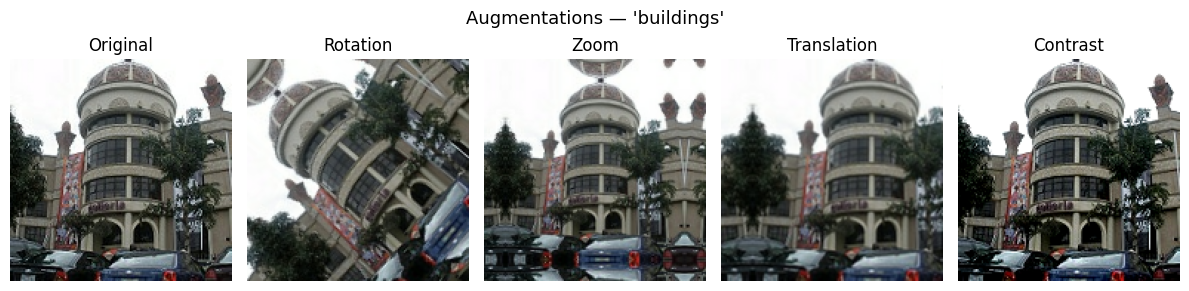

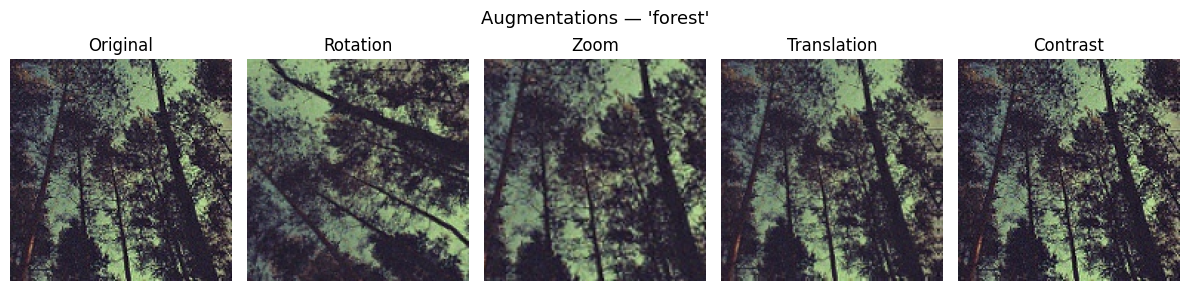

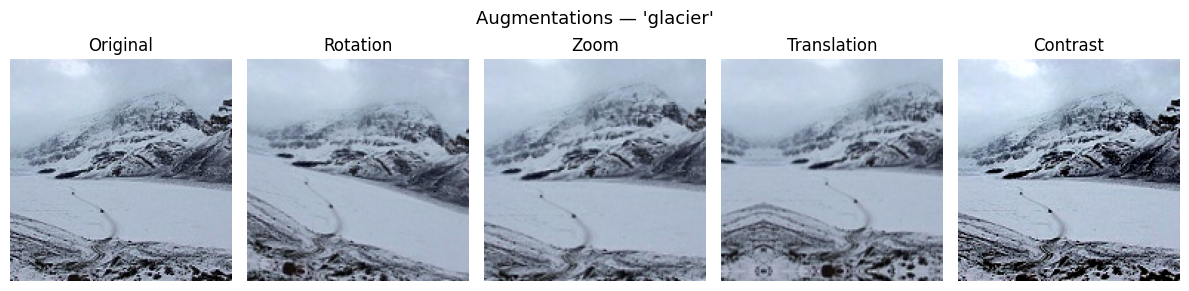

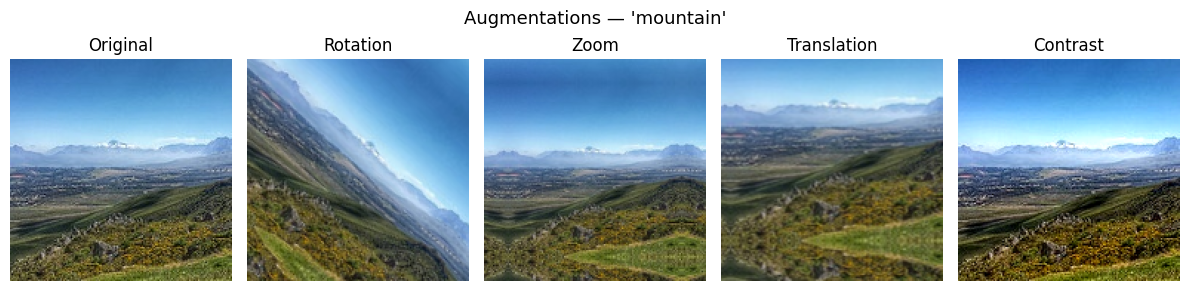

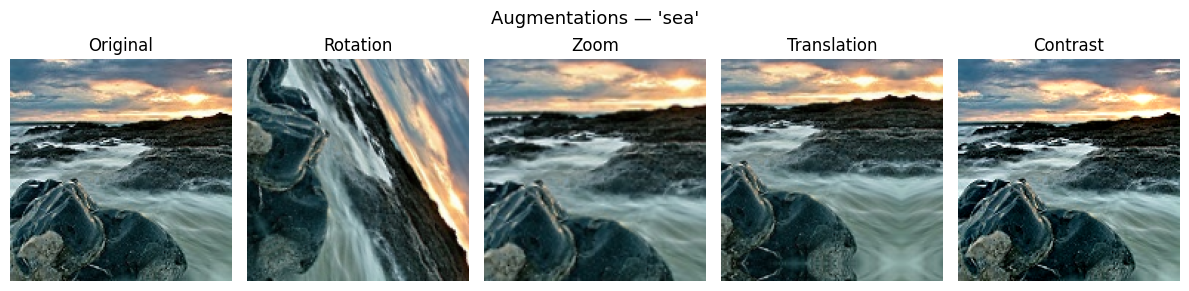

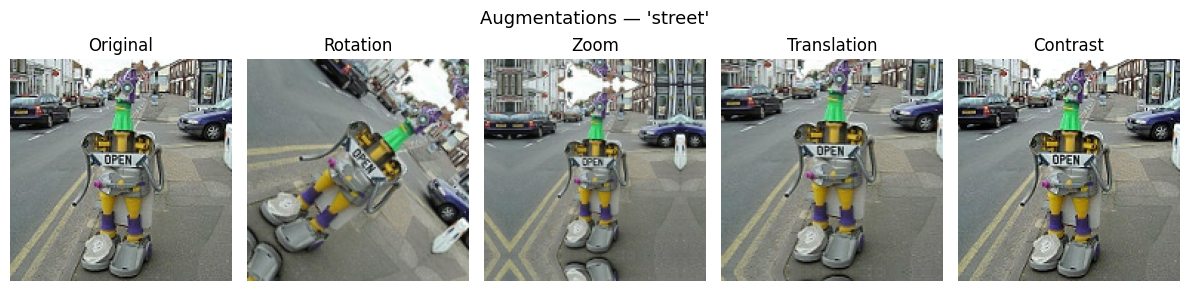

In [ ]:
# Data augmentation pipeline
augment_layer = keras.Sequential([
    keras.layers.RandomFlip('horizontal'),
    keras.layers.RandomRotation(0.15),
    keras.layers.RandomZoom(0.2),
    keras.layers.RandomTranslation(0.1, 0.1),
    keras.layers.RandomContrast(0.2),
], name='augmentation')

# Show augmented examples for each class
aug_ops = [
    (keras.layers.RandomRotation(0.2),        "Rotation"),
    (keras.layers.RandomZoom(0.3),             "Zoom"),
    (keras.layers.RandomTranslation(0.2, 0.2), "Translation"),
    (keras.layers.RandomContrast(0.4),         "Contrast"),
]

for cls_name in CLASS_NAMES:
    orig = np.array(random.choice(samples[cls_name]))
    fig, axes = plt.subplots(1, 5, figsize=(12, 3))
    axes[0].imshow(orig); axes[0].set_title("Original"); axes[0].axis('off')
    for i, (op, name) in enumerate(aug_ops, 1):
        t = tf.expand_dims(orig, 0)
        out = tf.clip_by_value(op(t, training=True)[0], 0.0, 1.0)
        axes[i].imshow(out.numpy()); axes[i].set_title(name); axes[i].axis('off')
    fig.suptitle(f"Augmentations — '{cls_name}'", fontsize=13)
    plt.tight_layout(); plt.show()


In [ ]:
print('Preprocessing Summary')
print('=' * 45)
print(f'  Resize        : {IMG_SIZE[0]}×{IMG_SIZE[1]} px')
print(f'  Normalisation : ÷ 255  →  [0.0, 1.0]')
print(f'  Batch size    : {BATCH_SIZE}')
print(f'  Split         : 80% train / 20% validation')
print(f'  Augmentation  : Flip, Rotation, Zoom, Translation, Contrast')
print(f'  Classes       : {CLASS_NAMES}')


Preprocessing Summary
  Resize        : 150×150 px
  Normalisation : ÷ 255  →  [0.0, 1.0]
  Batch size    : 32
  Split         : 80% train / 20% validation
  Augmentation  : Flip, Rotation, Zoom, Translation, Contrast
  Classes       : ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


---
## 2. Baseline CNN (Functional API)
3 Conv→Pool blocks + 3 Dense layers + Softmax output.

In [ ]:
def build_baseline(input_shape=(150,150,3), n_classes=6):
    """Baseline CNN built with the Functional API."""
    inp = Input(shape=input_shape)

    # Conv Block 1
    x = Conv2D(32, (3,3), activation='relu', padding='same')(inp)
    x = MaxPooling2D((2,2))(x)

    # Conv Block 2
    x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
    x = MaxPooling2D((2,2))(x)

    # Conv Block 3
    x = Conv2D(128, (3,3), activation='relu', padding='same')(x)
    x = MaxPooling2D((2,2))(x)

    # Classification head
    x = Flatten()(x)
    x = Dense(512, activation='relu')(x)
    x = Dense(256, activation='relu')(x)
    x = Dense(128, activation='relu')(x)
    out = Dense(n_classes, activation='softmax')(x)

    return Model(inp, out, name='Baseline_CNN')

baseline_model = build_baseline((*IMG_SIZE, 3), NUM_CLASSES)
baseline_model.summary()

Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    21,234,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,492,422 (81.99 MB)

 Trainable params: 21,492,422 (81.99 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
aug_train_ds = train_ds.map(
    lambda x, y: (augment_layer(x, training=True), y),
    num_parallel_calls=tf.data.AUTOTUNE)

baseline_model.compile(
    optimizer=Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])

base_cbs = [
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_baseline.keras', monitor='val_accuracy', save_best_only=True, verbose=0)
]

print("Training Baseline CNN …")
t0 = time.time()
baseline_hist = baseline_model.fit(
    aug_train_ds, validation_data=val_ds,
    epochs=25, callbacks=base_cbs, verbose=1)
base_time = time.time() - t0
print(f"Done  — {base_time:.0f}s  ({base_time/60:.1f} min)")


Training Baseline CNN …
Epoch 1/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 108s 287ms/step - accuracy: 0.5337 - loss: 1.1755 - val_accuracy: 0.5141 - val_loss: 1.4274
Epoch 2/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 129s 265ms/step - accuracy: 0.6205 - loss: 0.9853 - val_accuracy: 0.6141 - val_loss: 1.1021
Epoch 3/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 133s 241ms/step - accuracy: 0.6635 - loss: 0.8964 - val_accuracy: 0.6755 - val_loss: 0.8714
Epoch 4/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 80s 226ms/step - accuracy: 0.6851 - loss: 0.8421 - val_accuracy: 0.7194 - val_loss: 0.7682
Epoch 5/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 79s 224ms/step - accuracy: 0.7111 - loss: 0.7689 - val_accuracy: 0.7394 - val_loss: 0.7132
Epoch 6/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 76s 208ms/step - accuracy: 0.7353 - loss: 0.7174 - val_accuracy: 0.7265 - val_loss: 0.8120
Epoch 7/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 84s 215ms/step - accuracy: 0.7536 - loss: 0.6797 - val_accuracy: 0.7208 - val_loss: 0.8487
Epoch 8/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 73s 206ms/step -

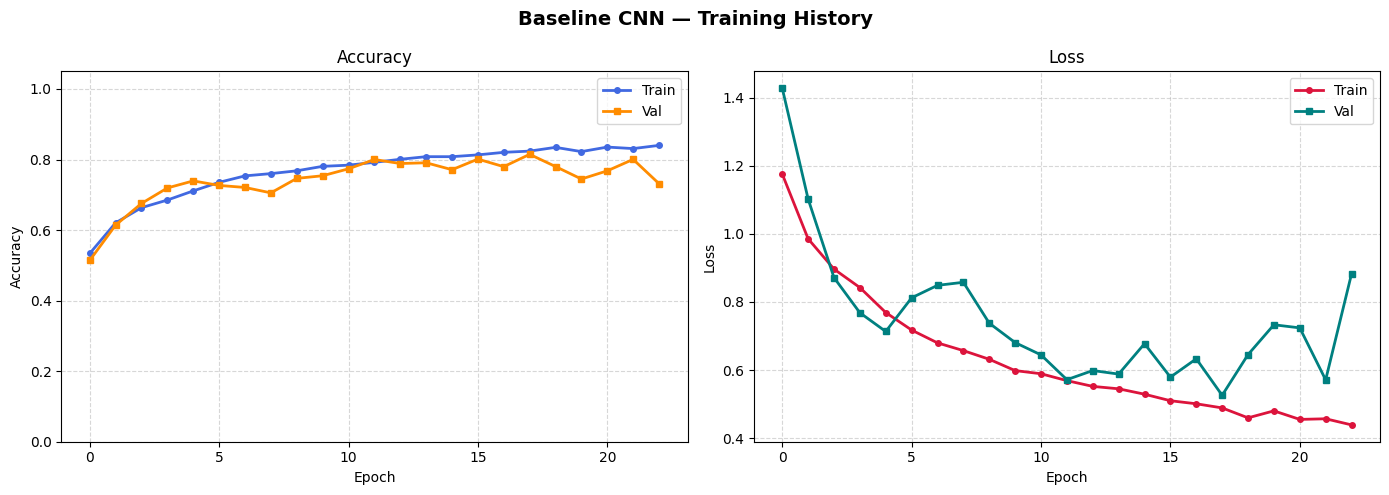

In [ ]:
def plot_curves(history, title='Training History'):
    """Plot accuracy and loss side-by-side."""
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    a1.plot(history.history['accuracy'],     label='Train', color='royalblue',  lw=2, marker='o', ms=4)
    a1.plot(history.history['val_accuracy'], label='Val',   color='darkorange', lw=2, marker='s', ms=4)
    a1.set_title('Accuracy'); a1.set_xlabel('Epoch'); a1.set_ylabel('Accuracy')
    a1.set_ylim(0, 1.05); a1.legend(); a1.grid(True, ls='--', alpha=0.5)

    a2.plot(history.history['loss'],     label='Train', color='crimson', lw=2, marker='o', ms=4)
    a2.plot(history.history['val_loss'], label='Val',   color='teal',    lw=2, marker='s', ms=4)
    a2.set_title('Loss'); a2.set_xlabel('Epoch'); a2.set_ylabel('Loss')
    a2.legend(); a2.grid(True, ls='--', alpha=0.5)
    plt.tight_layout(); plt.show()

plot_curves(baseline_hist, 'Baseline CNN — Training History')


=== Baseline CNN (Val) ===
              precision    recall  f1-score   support

   buildings       0.72      0.83      0.77       429
      forest       0.94      0.96      0.95       435
     glacier       0.80      0.73      0.77       474
    mountain       0.81      0.69      0.74       515
         sea       0.76      0.85      0.80       475
      street       0.87      0.85      0.86       473

    accuracy                           0.81      2801
   macro avg       0.82      0.82      0.82      2801
weighted avg       0.82      0.81      0.81      2801



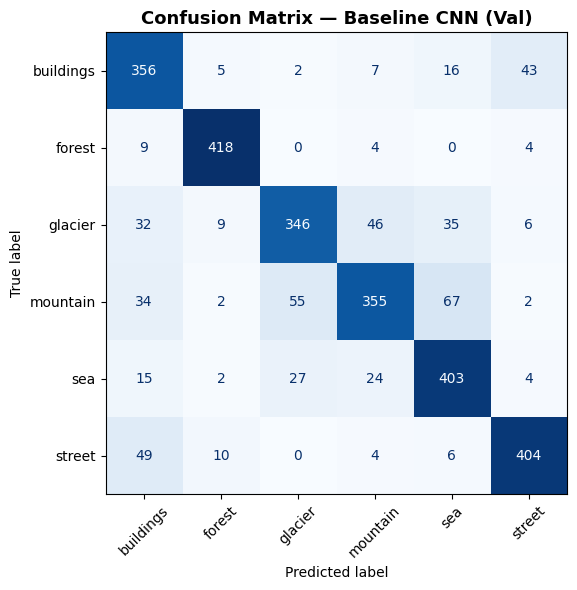

In [ ]:
def run_evaluation(model, ds, class_names, title='Evaluation'):
    y_true, y_pred = [], []
    for imgs, lbls in ds:
        preds = model.predict(imgs, verbose=0)
        y_true.extend(lbls.numpy())
        y_pred.extend(np.argmax(preds, axis=1))
    y_true, y_pred = np.array(y_true), np.array(y_pred)

    print(f"\n=== {title} ===")
    print(classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(8,6))
    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
        ax=ax, cmap='Blues', xticks_rotation=45, colorbar=False)
    ax.set_title(f'Confusion Matrix — {title}', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()
    return y_true, y_pred

base_yt, base_yp = run_evaluation(baseline_model, val_ds, CLASS_NAMES, 'Baseline CNN (Val)')


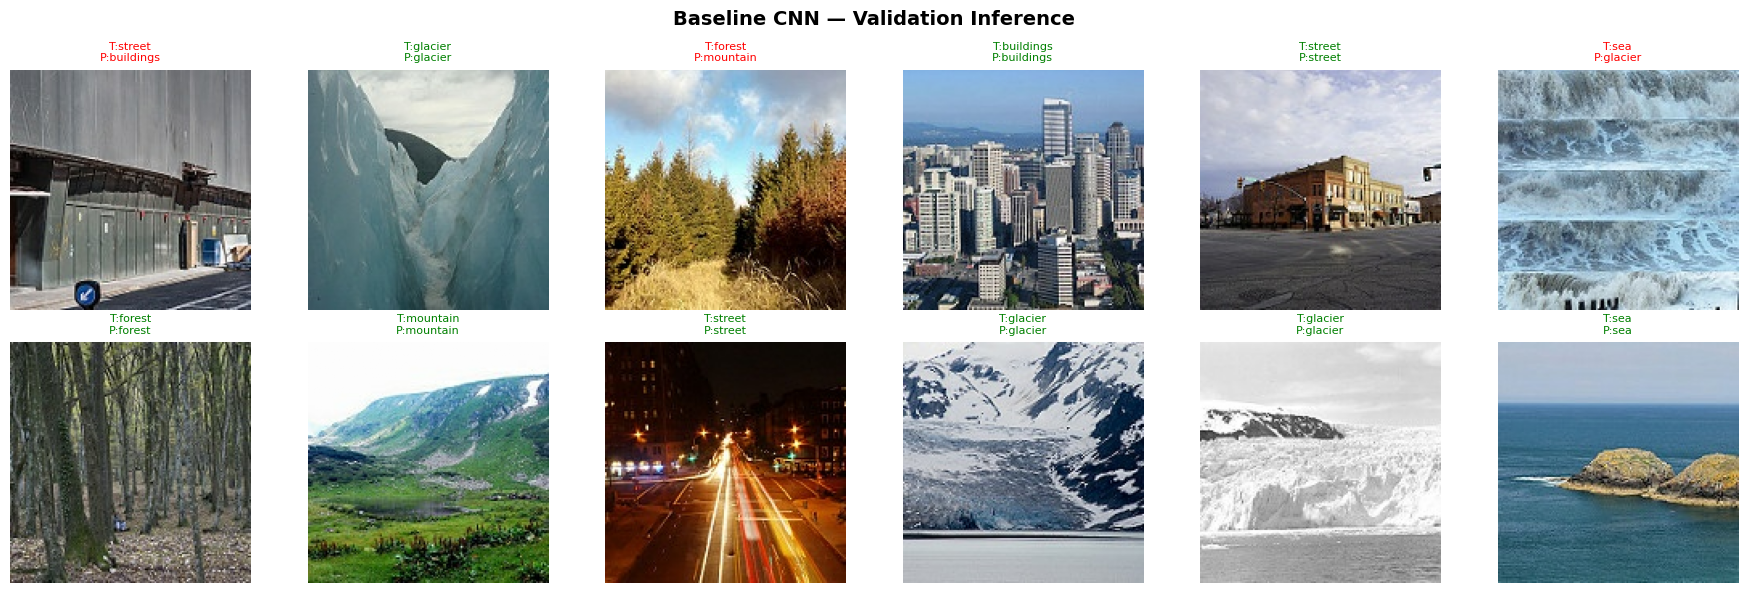

Green = correct  |  Red = incorrect


In [ ]:
# Inference samples
imgs_b, lbls_b = next(iter(val_ds))
preds_b = np.argmax(baseline_model.predict(imgs_b, verbose=0), axis=1)

fig, axes = plt.subplots(2, 6, figsize=(18, 6))
fig.suptitle('Baseline CNN — Validation Inference', fontsize=14, fontweight='bold')
for i, ax in enumerate(axes.flat):
    if i >= len(imgs_b): ax.axis('off'); continue
    ax.imshow(imgs_b[i].numpy()); ax.axis('off')
    tl = CLASS_NAMES[int(lbls_b[i].numpy())]; pl = CLASS_NAMES[preds_b[i]]
    ax.set_title(f'T:{tl}\nP:{pl}', fontsize=8, color='green' if tl==pl else 'red')
plt.tight_layout(); plt.show()
print("Green = correct  |  Red = incorrect")


### Baseline Observations
The baseline converges reasonably well. `mountain`↔`glacier` and `buildings`↔`street` are the most confused pairs due to visual similarity. Mild overfitting visible without explicit regularisation.

---
## 3. Deeper CNN with Regularisation
Doubles Conv layers, adds BatchNorm, Dropout, L2 to reduce overfitting.

In [ ]:
def build_deeper(input_shape=(150,150,3), n_classes=6, l2=1e-3):
    """Deeper Functional-API CNN with BatchNorm + Dropout + L2."""
    reg = regularizers.l2(l2)
    inp = x = Input(shape=input_shape)

    for filters, drop in [(32, 0.25), (64, 0.30), (128, 0.35), (256, 0.40)]:
        x = Conv2D(filters, (3,3), padding='same', activation='relu', kernel_regularizer=reg)(x)
        x = BatchNormalization()(x)
        x = Conv2D(filters, (3,3), padding='same', activation='relu', kernel_regularizer=reg)(x)
        x = BatchNormalization()(x)
        x = MaxPooling2D((2,2))(x)
        x = Dropout(drop)(x)

    x = GlobalAveragePooling2D()(x)
    for units, drop in [(512, 0.40), (256, 0.30), (128, 0.25)]:
        x = Dense(units, activation='relu', kernel_regularizer=reg)(x)
        x = BatchNormalization()(x)
        x = Dropout(drop)(x)

    out = Dense(n_classes, activation='softmax')(x)
    return Model(inp, out, name='Deeper_CNN')

deeper_model = build_deeper((*IMG_SIZE, 3), NUM_CLASSES)
deeper_model.summary()

Model: "Deeper_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 150, 150, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 75, 75, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 37, 37, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 18, 18, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,476,262 (5.63 MB)

 Trainable params: 1,472,550 (5.62 MB)

 Non-trainable params: 3,712 (14.50 KB)

### Deeper Model Analysis
- **8 Conv2D** layers learn richer hierarchical features vs 3 in baseline.
- **BatchNorm** stabilises activations, reduces internal covariate shift.
- **Dropout (0.25→0.40)** progressively increases in deeper blocks.
- **GlobalAveragePooling** reduces params vs Flatten.

Training Deeper CNN (Adam) …
Epoch 1/40
351/351 ━━━━━━━━━━━━━━━━━━━━ 128s 289ms/step - accuracy: 0.4611 - loss: 3.0781 - val_accuracy: 0.2342 - val_loss: 4.7977 - learning_rate: 5.0000e-04
Epoch 2/40
351/351 ━━━━━━━━━━━━━━━━━━━━ 81s 229ms/step - accuracy: 0.5552 - loss: 2.6729 - val_accuracy: 0.5891 - val_loss: 2.5466 - learning_rate: 5.0000e-04
Epoch 3/40
351/351 ━━━━━━━━━━━━━━━━━━━━ 80s 227ms/step - accuracy: 0.6141 - loss: 2.4113 - val_accuracy: 0.4784 - val_loss: 2.8332 - learning_rate: 5.0000e-04
Epoch 4/40
351/351 ━━━━━━━━━━━━━━━━━━━━ 83s 230ms/step - accuracy: 0.6508 - loss: 2.1715 - val_accuracy: 0.6801 - val_loss: 2.0349 - learning_rate: 5.0000e-04
Epoch 5/40
351/351 ━━━━━━━━━━━━━━━━━━━━ 79s 225ms/step - accuracy: 0.6780 - loss: 1.9678 - val_accuracy: 0.5162 - val_loss: 2.4460 - learning_rate: 5.0000e-04
Epoch 6/40
351/351 ━━━━━━━━━━━━━━━━━━━━ 82s 232ms/step - accuracy: 0.6963 - loss: 1.7783 - val_accuracy: 0.5944 - val_loss: 1.9837 - learning_rate: 5.0000e-04
Epoch 7/40
351/3

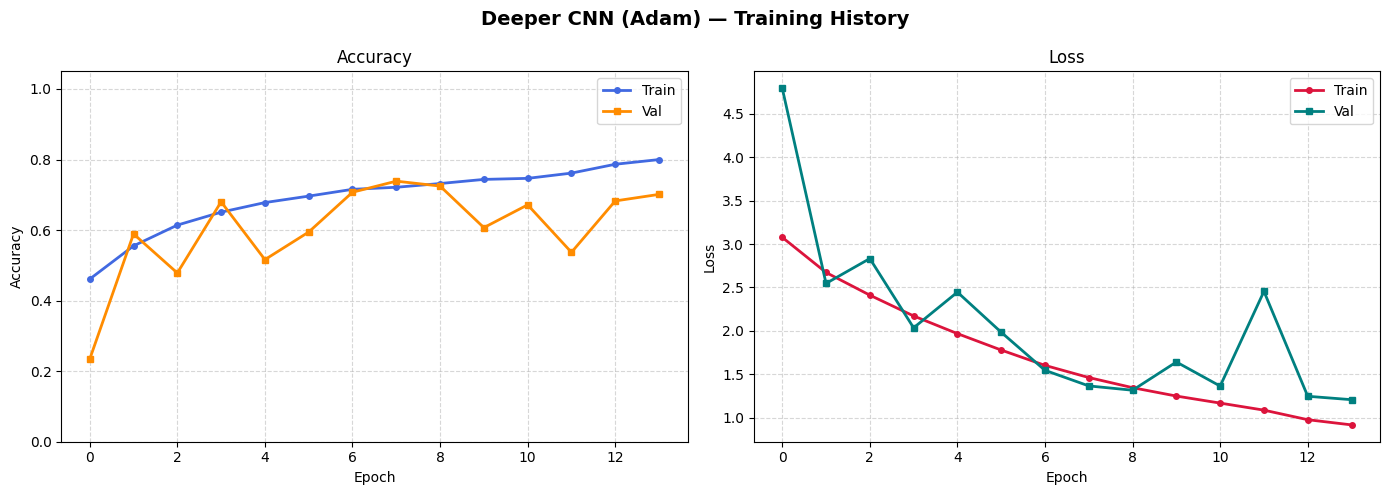


=== Deeper CNN Adam (Val) ===
              precision    recall  f1-score   support

   buildings       0.72      0.76      0.74       429
      forest       0.72      0.99      0.83       435
     glacier       0.70      0.76      0.73       474
    mountain       0.70      0.74      0.72       515
         sea       0.78      0.72      0.75       475
      street       0.91      0.49      0.63       473

    accuracy                           0.74      2801
   macro avg       0.75      0.74      0.73      2801
weighted avg       0.76      0.74      0.73      2801



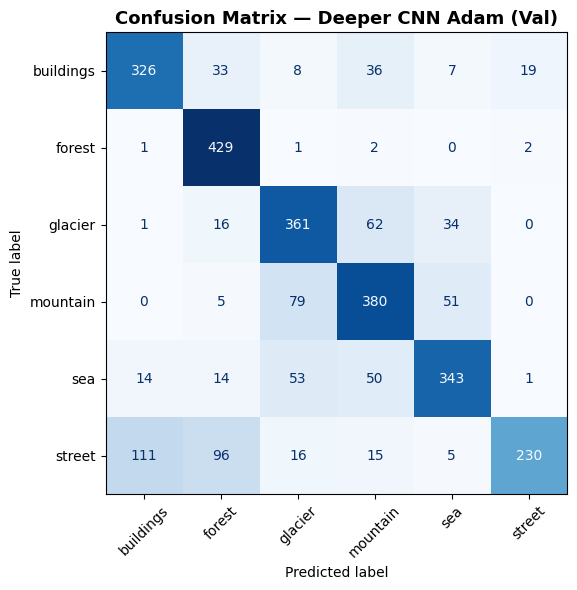

In [ ]:
deeper_model.compile(
    optimizer=Adam(5e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])

deep_cbs = [
    EarlyStopping(monitor='val_accuracy', patience=6, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_deeper_adam.keras', monitor='val_accuracy', save_best_only=True, verbose=0),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
]

print("Training Deeper CNN (Adam) …")
t0 = time.time()
hist_adam = deeper_model.fit(
    aug_train_ds, validation_data=val_ds,
    epochs=40, callbacks=deep_cbs, verbose=1)
adam_time = time.time() - t0
print(f"Done — {adam_time:.0f}s  ({adam_time/60:.1f} min)")

plot_curves(hist_adam, 'Deeper CNN (Adam) — Training History')
deep_yt, deep_yp = run_evaluation(deeper_model, val_ds, CLASS_NAMES, 'Deeper CNN Adam (Val)')


---
## 4. Experimentation & Comparative Analysis
### 4.1 Baseline vs Deeper

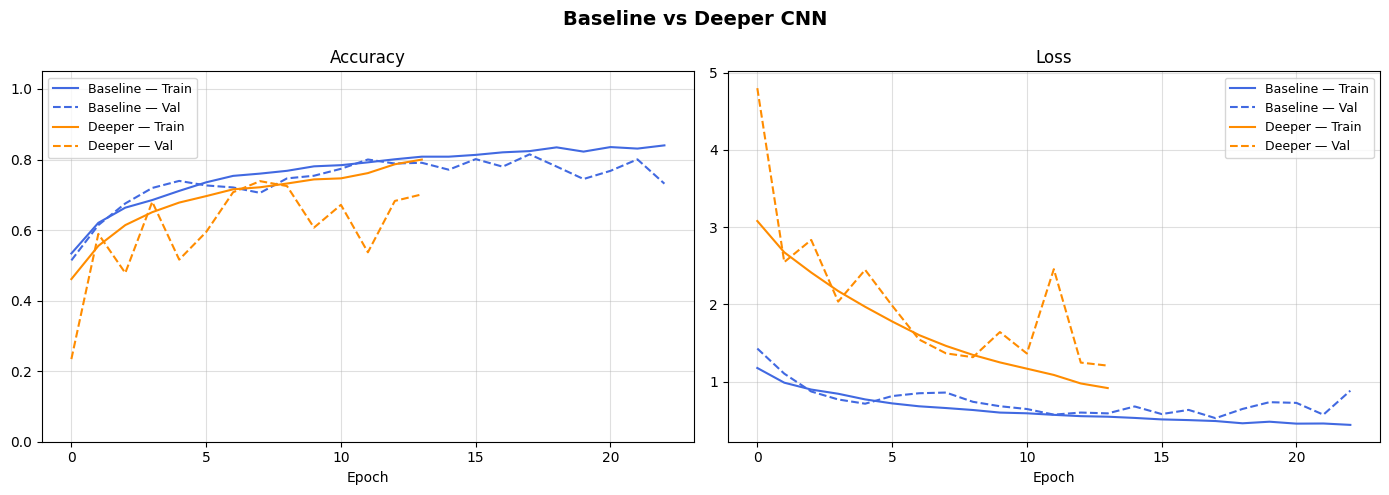

Best Val Accuracy  |  Baseline: 0.8147  |  Deeper: 0.7387


In [ ]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Baseline vs Deeper CNN', fontsize=14, fontweight='bold')

for ax, metric in zip([a1, a2], ['accuracy', 'loss']):
    ax.plot(baseline_hist.history[metric],          label='Baseline — Train', color='royalblue')
    ax.plot(baseline_hist.history[f'val_{metric}'], label='Baseline — Val',   color='royalblue',  ls='--')
    ax.plot(hist_adam.history[metric],              label='Deeper — Train',   color='darkorange')
    ax.plot(hist_adam.history[f'val_{metric}'],     label='Deeper — Val',     color='darkorange', ls='--')
    ax.set_title(metric.capitalize()); ax.set_xlabel('Epoch')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.4)
    if metric == 'accuracy': ax.set_ylim(0, 1.05)
plt.tight_layout(); plt.show()

print(f"Best Val Accuracy  |  Baseline: {max(baseline_hist.history['val_accuracy']):.4f}"
      f"  |  Deeper: {max(hist_adam.history['val_accuracy']):.4f}")


### 4.2 Computational Efficiency

Baseline params : 21,492,422
Deeper   params : 1,476,262  (0.1×)
Baseline time   : 1961s
Deeper   time   : 1185s  (0.6×)


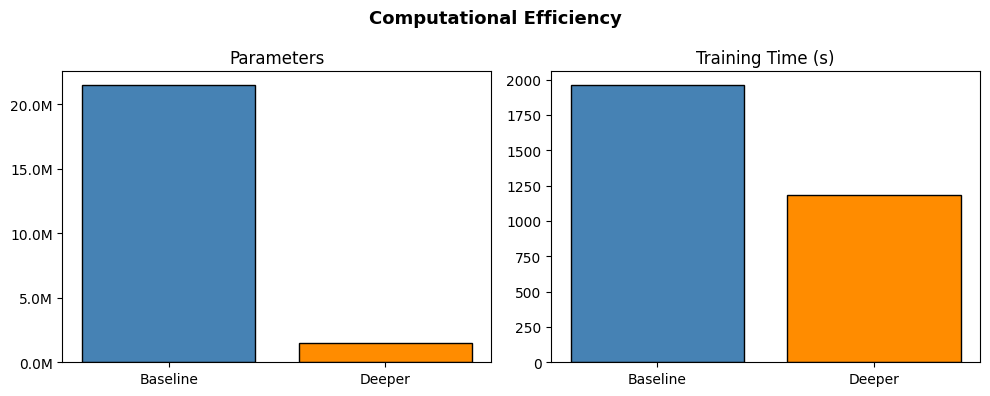

In [ ]:
bp = baseline_model.count_params(); dp = deeper_model.count_params()
print(f"Baseline params : {bp:,}")
print(f"Deeper   params : {dp:,}  ({dp/bp:.1f}×)")
print(f"Baseline time   : {base_time:.0f}s")
print(f"Deeper   time   : {adam_time:.0f}s  ({adam_time/base_time:.1f}×)")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('Computational Efficiency', fontsize=13, fontweight='bold')
a1.bar(['Baseline','Deeper'], [bp, dp], color=['steelblue','darkorange'], edgecolor='black')
a1.set_title('Parameters'); a1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x/1e6:.1f}M'))
a2.bar(['Baseline','Deeper'], [base_time, adam_time], color=['steelblue','darkorange'], edgecolor='black')
a2.set_title('Training Time (s)')
plt.tight_layout(); plt.show()


### 4.3 Optimizer Comparison — SGD vs Adam

In [ ]:
sgd_model = build_deeper((*IMG_SIZE, 3), NUM_CLASSES)
sgd_model.compile(
    optimizer=SGD(5e-3, momentum=0.9, nesterov=True),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])

sgd_cbs = [
    EarlyStopping(monitor='val_accuracy', patience=6, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_deeper_sgd.keras', monitor='val_accuracy', save_best_only=True, verbose=0)
]

print("Training Deeper CNN (SGD+Nesterov) …")
t0 = time.time()
hist_sgd = sgd_model.fit(
    aug_train_ds, validation_data=val_ds,
    epochs=40, callbacks=sgd_cbs, verbose=1)
sgd_time = time.time() - t0
print(f"Done — {sgd_time:.0f}s  ({sgd_time/60:.1f} min)")


Training Deeper CNN (SGD+Nesterov) …
Epoch 1/40
351/351 ━━━━━━━━━━━━━━━━━━━━ 110s 267ms/step - accuracy: 0.4560 - loss: 3.0514 - val_accuracy: 0.3984 - val_loss: 2.9649
Epoch 2/40
351/351 ━━━━━━━━━━━━━━━━━━━━ 118s 230ms/step - accuracy: 0.5413 - loss: 2.7053 - val_accuracy: 0.4773 - val_loss: 3.0064
Epoch 3/40
351/351 ━━━━━━━━━━━━━━━━━━━━ 81s 227ms/step - accuracy: 0.5903 - loss: 2.5115 - val_accuracy: 0.6098 - val_loss: 2.3982
Epoch 4/40
351/351 ━━━━━━━━━━━━━━━━━━━━ 82s 228ms/step - accuracy: 0.6301 - loss: 2.3450 - val_accuracy: 0.6690 - val_loss: 2.2358
Epoch 5/40
351/351 ━━━━━━━━━━━━━━━━━━━━ 83s 235ms/step - accuracy: 0.6510 - loss: 2.2080 - val_accuracy: 0.6976 - val_loss: 2.0662
Epoch 6/40
351/351 ━━━━━━━━━━━━━━━━━━━━ 81s 230ms/step - accuracy: 0.6673 - loss: 2.0889 - val_accuracy: 0.7080 - val_loss: 1.9553
Epoch 7/40
351/351 ━━━━━━━━━━━━━━━━━━━━ 82s 232ms/step - accuracy: 0.6890 - loss: 1.9664 - val_accuracy: 0.6640 - val_loss: 2.0276
Epoch 8/40
351/351 ━━━━━━━━━━━━━━━━━━━━ 81s 

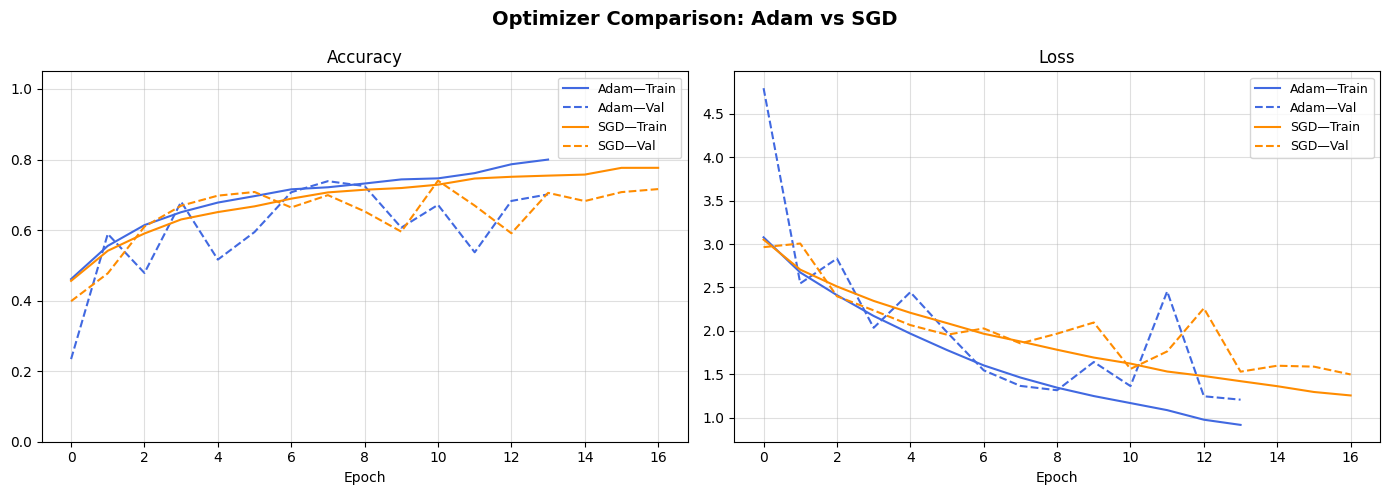

Adam best val acc: 0.7387
SGD  best val acc: 0.7401
Adam typically converges faster; SGD may match given more epochs.

=== Deeper CNN SGD (Val) ===
              precision    recall  f1-score   support

   buildings       0.59      0.85      0.70       429
      forest       0.90      0.95      0.92       435
     glacier       0.77      0.65      0.70       474
    mountain       0.72      0.67      0.69       515
         sea       0.69      0.86      0.77       475
      street       0.90      0.50      0.64       473

    accuracy                           0.74      2801
   macro avg       0.76      0.75      0.74      2801
weighted avg       0.76      0.74      0.74      2801



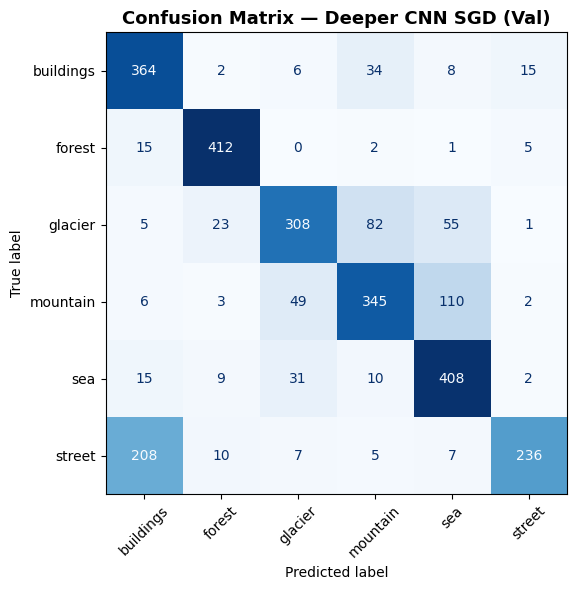

In [ ]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Optimizer Comparison: Adam vs SGD', fontsize=14, fontweight='bold')
for ax, m in zip([a1,a2], ['accuracy','loss']):
    ax.plot(hist_adam.history[m],          label='Adam—Train', color='royalblue')
    ax.plot(hist_adam.history[f'val_{m}'], label='Adam—Val',   color='royalblue',  ls='--')
    ax.plot(hist_sgd.history[m],           label='SGD—Train',  color='darkorange')
    ax.plot(hist_sgd.history[f'val_{m}'],  label='SGD—Val',    color='darkorange', ls='--')
    ax.set_title(m.capitalize()); ax.set_xlabel('Epoch')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.4)
    if m == 'accuracy': ax.set_ylim(0, 1.05)
plt.tight_layout(); plt.show()

print(f"Adam best val acc: {max(hist_adam.history['val_accuracy']):.4f}")
print(f"SGD  best val acc: {max(hist_sgd.history['val_accuracy']):.4f}")
print("Adam typically converges faster; SGD may match given more epochs.")

sgd_yt, sgd_yp = run_evaluation(sgd_model, val_ds, CLASS_NAMES, 'Deeper CNN SGD (Val)')


### 4.4 Ablation Study — Effect of Dropout

In [ ]:
def build_no_dropout(input_shape=(150,150,3), n_classes=6, l2=1e-3):
    """Same as deeper model but WITHOUT any Dropout layers."""
    reg = regularizers.l2(l2)
    inp = x = Input(shape=input_shape)
    for filters in [32, 64, 128, 256]:
        x = Conv2D(filters,(3,3),padding='same',activation='relu',kernel_regularizer=reg)(x)
        x = BatchNormalization()(x);
        x = Conv2D(filters,(3,3),padding='same',activation='relu',kernel_regularizer=reg)(x)
        x = BatchNormalization()(x)
        x = MaxPooling2D((2,2))(x)
    x = GlobalAveragePooling2D()(x)
    for units in [512, 256, 128]:
        x = Dense(units, activation='relu', kernel_regularizer=reg)(x)
        x = BatchNormalization()(x)
    out = Dense(n_classes, activation='softmax')(x)
    return Model(inp, out, name='NoDrop_CNN')

ablated_model = build_no_dropout((*IMG_SIZE, 3), NUM_CLASSES)
ablated_model.compile(optimizer=Adam(5e-4), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("Training Ablated Model (no Dropout) …")
hist_abl = ablated_model.fit(
    aug_train_ds, validation_data=val_ds, epochs=30,
    callbacks=[EarlyStopping(monitor='val_accuracy',patience=5,restore_best_weights=True,verbose=1)],
    verbose=1)

print(f"Deeper WITH Dropout : {max(hist_adam.history['val_accuracy']):.4f}")
print(f"Ablated  NO Dropout : {max(hist_abl.history['val_accuracy']):.4f}")

Training Ablated Model (no Dropout) …
Epoch 1/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 111s 277ms/step - accuracy: 0.5439 - loss: 2.7976 - val_accuracy: 0.3049 - val_loss: 3.5410
Epoch 2/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 81s 229ms/step - accuracy: 0.6451 - loss: 2.4105 - val_accuracy: 0.6958 - val_loss: 2.2297
Epoch 3/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 82s 228ms/step - accuracy: 0.6789 - loss: 2.1487 - val_accuracy: 0.7101 - val_loss: 1.9515
Epoch 4/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 81s 230ms/step - accuracy: 0.7125 - loss: 1.8944 - val_accuracy: 0.6676 - val_loss: 1.9970
Epoch 5/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 81s 228ms/step - accuracy: 0.7265 - loss: 1.6866 - val_accuracy: 0.6705 - val_loss: 1.7563
Epoch 6/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 82s 233ms/step - accuracy: 0.7417 - loss: 1.4924 - val_accuracy: 0.6858 - val_loss: 1.6197
Epoch 7/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 80s 228ms/step - accuracy: 0.7531 - loss: 1.3476 - val_accuracy: 0.7444 - val_loss: 1.3876
Epoch 8/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 82s 

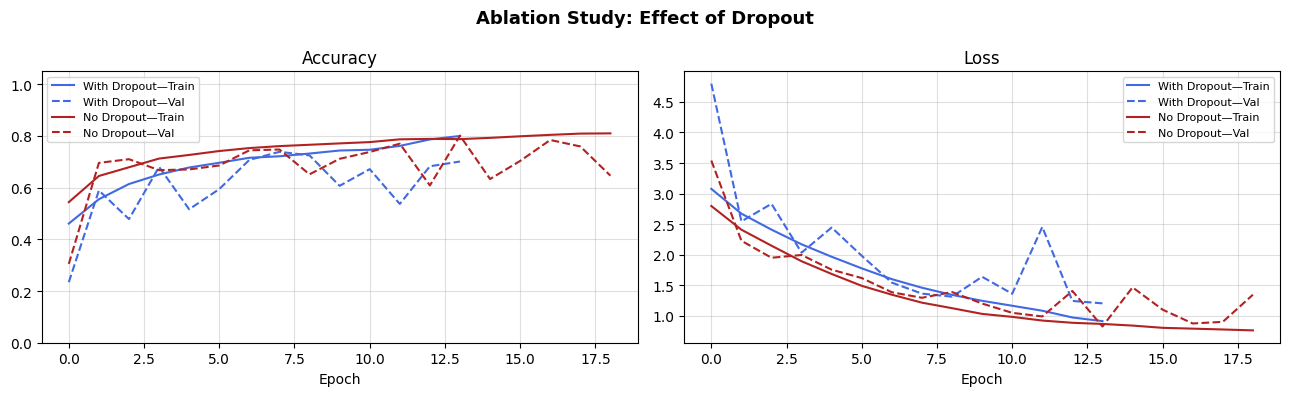

In [ ]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Ablation Study: Effect of Dropout', fontsize=13, fontweight='bold')
for ax, m in zip([a1,a2],['accuracy','loss']):
    ax.plot(hist_adam.history[m],          label='With Dropout—Train', color='royalblue')
    ax.plot(hist_adam.history[f'val_{m}'], label='With Dropout—Val',   color='royalblue',  ls='--')
    ax.plot(hist_abl.history[m],           label='No Dropout—Train',   color='firebrick')
    ax.plot(hist_abl.history[f'val_{m}'],  label='No Dropout—Val',     color='firebrick',  ls='--')
    ax.set_title(m.capitalize()); ax.set_xlabel('Epoch')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.4)
    if m=='accuracy': ax.set_ylim(0,1.05)
plt.tight_layout(); plt.show()


**Observations:** Without Dropout, training accuracy climbs faster but the train–val gap widens (overfitting). Dropout is an effective regulariser even alongside BatchNorm and L2.

### 4.5 Challenges and Observations

| Challenge | Observation | Mitigation |
|---|---|---|
| Overfitting (baseline) | Train >> Val accuracy | Dropout, BatchNorm, L2, Augmentation |
| Class confusion | mountain↔glacier, buildings↔street | Deeper features |
| Slow SGD convergence | SGD needs more epochs | Nesterov + LR scheduling |
| Training time | Deeper 2-4× slower | GPU acceleration |

In [ ]:
print('=== Training Time Summary ===')
print(f'  Baseline CNN      : {base_time:.0f}s  ({base_time/60:.1f} min)')
print(f'  Deeper CNN (Adam) : {adam_time:.0f}s  ({adam_time/60:.1f} min)')
print(f'  Deeper CNN (SGD)  : {sgd_time:.0f}s  ({sgd_time/60:.1f} min)')


=== Training Time Summary ===
  Baseline CNN      : 1961s  (32.7 min)
  Deeper CNN (Adam) : 1185s  (19.7 min)
  Deeper CNN (SGD)  : 1462s  (24.4 min)


---
# Part B — Transfer Learning: MobileNetV2

**Strategy:** (1) Feature Extraction — freeze base, train head only. (2) Fine-Tuning — unfreeze top 30 layers with tiny LR.

**Why MobileNetV2?** Lightweight, efficient, accepts 150×150 input, pre-trained on natural/urban scenes (ImageNet) — ideal match for this task.

In [ ]:
import os, random, time
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, UnidentifiedImageError
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Input
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Dense, Flatten,
    Dropout, BatchNormalization, GlobalAveragePooling2D)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import regularizers

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

BASE_DIR  = '/content/drive/MyDrive/AI and ML/Data/Scene Classification'
train_dir = os.path.join(BASE_DIR, '/content/drive/MyDrive/AI and ML/Data/Scene Classification/train')
test_dir  = os.path.join(BASE_DIR, '/content/drive/MyDrive/AI and ML/Data/Scene Classification/test')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
IMG_SIZE   = (150, 150)
BATCH_SIZE = 32

train_raw = tf.keras.utils.image_dataset_from_directory(
    train_dir, validation_split=0.2, subset='training',
    seed=SEED, image_size=IMG_SIZE, batch_size=BATCH_SIZE)

val_raw = tf.keras.utils.image_dataset_from_directory(
    train_dir, validation_split=0.2, subset='validation',
    seed=SEED, image_size=IMG_SIZE, batch_size=BATCH_SIZE)

CLASS_NAMES = train_raw.class_names
NUM_CLASSES = len(CLASS_NAMES)
print(f"Classes: {CLASS_NAMES}")

Found 14008 files belonging to 6 classes.
Using 11207 files for training.
Found 14008 files belonging to 6 classes.
Using 2801 files for validation.
Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [ ]:
mobilenet_preprocess = tf.keras.applications.mobilenet_v2.preprocess_input

tl_train_ds = (train_raw
    .map(lambda x,y: (mobilenet_preprocess(x), y), num_parallel_calls=tf.data.AUTOTUNE)
    .map(lambda x,y: (augment_layer(x, training=True), y), num_parallel_calls=tf.data.AUTOTUNE)
    .cache().shuffle(1000, seed=SEED).prefetch(tf.data.AUTOTUNE))

tl_val_ds = (val_raw
    .map(lambda x,y: (mobilenet_preprocess(x), y), num_parallel_calls=tf.data.AUTOTUNE)
    .cache().prefetch(tf.data.AUTOTUNE))

print("TL datasets ready.")


TL datasets ready.


In [ ]:
# Build TL model using Functional API
base_net = MobileNetV2(weights='imagenet', include_top=False, input_shape=(*IMG_SIZE, 3))
base_net.trainable = False

inp = Input(shape=(*IMG_SIZE, 3))
x = base_net(inp, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
out = Dense(NUM_CLASSES, activation='softmax')(x)

tl_model = Model(inp, out, name='MobileNetV2_TL')
print(f"Trainable params  : {tl_model.count_params():,}")
print(f"Base (frozen)     : {base_net.count_params():,}")
tl_model.summary()


/tmp/ipykernel_52317/3029143012.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_net = MobileNetV2(weights='imagenet', include_top=False, input_shape=(*IMG_SIZE, 3))


Trainable params  : 3,048,774
Base (frozen)     : 2,257,984


Model: "MobileNetV2_TL"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_33          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,048,774 (11.63 MB)

 Trainable params: 789,766 (3.01 MB)

 Non-trainable params: 2,259,008 (8.62 MB)

In [ ]:
# Phase 2 — Fine-Tuning (unfreeze top 30 layers)
base_net.trainable = True
for layer in base_net.layers[:-30]: layer.trainable = False

tl_model.compile(optimizer=Adam(1e-5), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

ft_cbs = [
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_ft.keras', monitor='val_accuracy', save_best_only=True, verbose=0)
]

print("Phase 2 — Fine-Tuning (top 30 layers unfrozen) …")
t0 = time.time()
hist_ft = tl_model.fit(tl_train_ds, validation_data=tl_val_ds, epochs=25, callbacks=ft_cbs, verbose=1)
ft_time = time.time() - t0
print(f"Done — {ft_time:.0f}s  ({ft_time/60:.1f} min)")


Phase 2 — Fine-Tuning (top 30 layers unfrozen) …
Epoch 1/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.2571 - loss: 2.3368

In [ ]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Transfer Learning — Feature Extraction vs Fine-Tuning', fontsize=14, fontweight='bold')
for ax, m in zip([a1,a2],['accuracy','loss']):
    ax.plot(hist_fe.history[m],          label='FE—Train', color='#45aaf2', lw=2, marker='o', ms=4)
    ax.plot(hist_fe.history[f'val_{m}'], label='FE—Val',   color='#a5dff9', lw=2, ls='--', marker='s', ms=4)
    ax.plot(hist_ft.history[m],          label='FT—Train', color='#eb4d4b', lw=2, marker='o', ms=4)
    ax.plot(hist_ft.history[f'val_{m}'], label='FT—Val',   color='#f5b7b1', lw=2, ls='--', marker='s', ms=4)
    ax.set_title(m.capitalize()); ax.set_xlabel('Epoch')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.4)
    if m=='accuracy': ax.set_ylim(0,1.05)
plt.tight_layout(); plt.show()


In [ ]:
tl_yt, tl_yp = run_evaluation(tl_model, tl_val_ds, CLASS_NAMES, 'MobileNetV2 Fine-Tuned (Val)')

# Inference samples
imgs_tl, lbls_tl = next(iter(tl_val_ds))
preds_tl = np.argmax(tl_model.predict(imgs_tl, verbose=0), axis=1)
display_tl = np.clip((imgs_tl.numpy() + 1.0) / 2.0, 0, 1)

fig, axes = plt.subplots(2, 6, figsize=(18, 6))
fig.suptitle('MobileNetV2 — Validation Inference', fontsize=14, fontweight='bold')
for i, ax in enumerate(axes.flat):
    if i >= len(display_tl): ax.axis('off'); continue
    ax.imshow(display_tl[i]); ax.axis('off')
    tl = CLASS_NAMES[int(lbls_tl[i].numpy())]; pl = CLASS_NAMES[preds_tl[i]]
    ax.set_title(f'T:{tl}\nP:{pl}', fontsize=8, color='green' if tl==pl else 'red')
plt.tight_layout(); plt.show()


---
## Final Comparison — All Models

In [ ]:
results = [
    ('Baseline CNN',          base_yt,  base_yp),
    ('Deeper CNN (Adam)',     deep_yt,  deep_yp),
    ('Deeper CNN (SGD)',      sgd_yt,   sgd_yp),
    ('MobileNetV2 Fine-Tune', tl_yt,    tl_yp),
]

print(f"{'Model':<26}  {'Accuracy':>10}  {'Macro F1':>10}")
print('-' * 52)
names, accs, f1s = [], [], []
for name, yt, yp in results:
    a = accuracy_score(yt, yp); f = f1_score(yt, yp, average='macro')
    print(f"{name:<26}  {a:>10.4f}  {f:>10.4f}")
    names.append(name); accs.append(a); f1s.append(f)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('All Models — Final Performance', fontsize=13, fontweight='bold')
colors = ['steelblue','darkorange','seagreen','crimson']
for ax, vals, lbl in zip([a1,a2],[accs,f1s],['Validation Accuracy','Macro F1-Score']):
    ax.bar(names, vals, color=colors, edgecolor='black')
    ax.set_title(lbl); ax.set_ylim(0,1.0)
    ax.set_xticklabels(names, rotation=15, ha='right', fontsize=9)
    for i,v in enumerate(vals): ax.text(i, v+0.01, f'{v:.3f}', ha='center', fontsize=9)
plt.tight_layout(); plt.show()


---
## Conclusion

1. **Baseline CNN** — good starting point, mild overfitting without regularisation.
2. **Deeper CNN (Adam)** — BatchNorm + Dropout + L2 reduces overfitting; confirmed by ablation study.
3. **Adam vs SGD** — Adam converges faster; SGD can match with more epochs and Nesterov momentum.
4. **MobileNetV2** — highest accuracy with least training effort; ImageNet features transfer well to natural scenes.

### Future Work
- EfficientNetV2 / ConvNeXt for better accuracy-efficiency trade-off  
- Test-time augmentation (TTA)  
- Class-weighted loss for imbalance  
- Hyperparameter search (Keras Tuner / Optuna)  
- Gradio / Streamlit deployment


---
## Final Evaluation on Unseen Test Set
Test set was kept completely unseen during training. Now evaluating all models on it.

In [ ]:
# ── Build test dataset pipeline ──────────────────────────────────
test_ds_raw = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Normalise for scratch models
test_ds = (test_ds_raw
           .map(norm, num_parallel_calls=tf.data.AUTOTUNE)
           .prefetch(tf.data.AUTOTUNE))

# Preprocess for MobileNetV2
tl_test_ds = (test_ds_raw
              .map(lambda x, y: (mobilenet_preprocess(x), y),
                   num_parallel_calls=tf.data.AUTOTUNE)
              .prefetch(tf.data.AUTOTUNE))

print("Test datasets ready.")
print(f"Test batches : {len(test_ds)}")


In [ ]:
# ── Evaluate all models on test set ─────────────────────────────
print("=" * 55)
print("  FINAL TEST SET EVALUATION — All Models")
print("=" * 55)

test_base_yt,  test_base_yp  = run_evaluation(baseline_model, test_ds,    CLASS_NAMES, 'Baseline CNN (Test Set)')
test_deep_yt,  test_deep_yp  = run_evaluation(deeper_model,   test_ds,    CLASS_NAMES, 'Deeper CNN Adam (Test Set)')
test_sgd_yt,   test_sgd_yp   = run_evaluation(sgd_model,      test_ds,    CLASS_NAMES, 'Deeper CNN SGD (Test Set)')
test_tl_yt,    test_tl_yp    = run_evaluation(tl_model,       tl_test_ds, CLASS_NAMES, 'MobileNetV2 Fine-Tuned (Test Set)')


In [ ]:
# ── Final test set comparison bar chart ─────────────────────────
from sklearn.metrics import accuracy_score, f1_score

test_results = [
    ('Baseline CNN',          test_base_yt,  test_base_yp),
    ('Deeper CNN (Adam)',     test_deep_yt,  test_deep_yp),
    ('Deeper CNN (SGD)',      test_sgd_yt,   test_sgd_yp),
    ('MobileNetV2 Fine-Tune', test_tl_yt,    test_tl_yp),
]

test_names, test_accs, test_f1s = [], [], []
print(f"{'Model':<26}  {'Test Acc':>10}  {'Macro F1':>10}")
print('-' * 52)
for name, yt, yp in test_results:
    a = accuracy_score(yt, yp); f = f1_score(yt, yp, average='macro')
    print(f"{name:<26}  {a:>10.4f}  {f:>10.4f}")
    test_names.append(name); test_accs.append(a); test_f1s.append(f)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('All Models — Final TEST SET Performance', fontsize=13, fontweight='bold')
colors = ['steelblue', 'darkorange', 'seagreen', 'crimson']
for ax, vals, lbl in zip([a1, a2], [test_accs, test_f1s], ['Test Accuracy', 'Macro F1']):
    ax.bar(test_names, vals, color=colors, edgecolor='black')
    ax.set_title(lbl); ax.set_ylim(0, 1.0)
    ax.set_xticklabels(test_names, rotation=15, ha='right', fontsize=9)
    for i, v in enumerate(vals):
        ax.text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)
plt.tight_layout(); plt.show()

print("\nMobileNetV2 typically achieves highest test accuracy due to ImageNet pretraining.")
